# Kaggle - Binary Prediction of Poisonous Mushrooms

## Competition Context
This competition is part of the Tabular Playground Series (S4E8).
The goal is to predict the class of a mushroom from its physical characteristics.

## Prediction Objective
For each observation in the test set, you must predict the target variable `class`:
- `e`: edible
- `p`: poisonous

This is a **binary classification** problem.

## Expected Submission Format
The submission file must contain two columns:
- `id`
- `class`

Example:
```text
id,class
3116945,e
3116946,p
3116947,e
```

## Dataset Analysis

In this section, we aim to understand the structure and quality of the dataset before modeling.

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
if not (ROOT / "data" / "train.csv").exists():
    ROOT = ROOT.parent

train_path = ROOT / "data" / "train.csv"
test_path = ROOT / "data" / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
print(f"Train file  : {train_path}")
print(f"Test file   : {test_path}")

Train shape: (3116945, 22)
Test shape : (2077964, 21)
Train file  : c:\Users\Antoine\Documents\UTBM\DS52\MushroomPrediction\mushroom-prediction\data\train.csv
Test file   : c:\Users\Antoine\Documents\UTBM\DS52\MushroomPrediction\mushroom-prediction\data\test.csv


## 1) Data Inventory

Questions to answer:
- How many rows and columns are in train and test?
- Which columns are categorical, numerical, or mixed?
- Is there any identifier column that should not be used as a feature?


In [2]:
train_feature_cols = [c for c in train_df.columns if c != "class"]

def describe_columns(df: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append(
            {
                "dataset": name,
                "column": col,
                "dtype": str(s.dtype),
                "n_unique": s.nunique(dropna=True),
                "missing_pct": round(s.isna().mean() * 100, 2),
                "kind": (
                    "identifier" if col.lower() == "id"
                    else "target" if col == "class"
                    else "categorical" if s.dtype == "object"
                    else "numeric"
                ),
            }
        )
    return pd.DataFrame(rows)

inventory = pd.concat(
    [describe_columns(train_df, "train"), describe_columns(test_df, "test")],
    ignore_index=True,
)

shape_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "columns": [train_df.shape[1], test_df.shape[1]],
    }
)

print("Dataset shape summary:")
display(shape_summary)

print("Column-level inventory (first 20 rows):")
display(inventory.head(20))

print("Feature dtype distribution (train, excluding target):")
display(train_df[train_feature_cols].dtypes.value_counts().rename_axis("dtype").reset_index(name="count"))

Dataset shape summary:


,dataset,rows,columns
0,train,3116945,22
1,test,2077964,21


Column-level inventory (first 20 rows):


,dataset,column,dtype,n_unique,missing_pct,kind
0,train,id,int64,3116945,0.00,identifier
1,train,class,str,2,0.00,target
2,train,cap-diameter,float64,3913,0.00,numeric
3,train,cap-shape,str,74,0.00,numeric
4,train,cap-surface,str,83,21.53,numeric
5,train,cap-color,str,78,0.00,numeric
6,train,does-bruise-or-bleed,str,26,0.00,numeric
7,train,gill-attachment,str,78,16.81,numeric
8,train,gill-spacing,str,48,40.37,numeric
9,train,gill-color,str,63,0.00,numeric


Feature dtype distribution (train, excluding target):


,dtype,count
0,str,17
1,float64,3
2,int64,1


## 2) Target Variable Analysis (`class`)

Questions to answer:
- Is the target balanced or imbalanced?
- What is the proportion of `e` vs `p`?

,count,percent
class,,
p,1705396,54.71
e,1411549,45.29


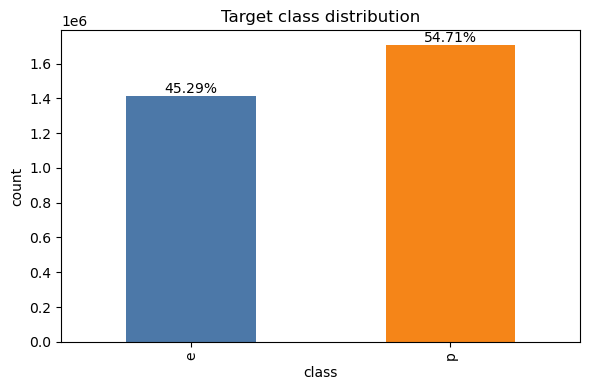

Imbalance ratio (majority/minority): 1.208
Recommendation: use Stratified K-Fold for validation.


In [3]:
if "class" not in train_df.columns:
    raise ValueError("Column 'class' was not found in train.csv")

target_counts = train_df["class"].value_counts(dropna=False)
target_pct = train_df["class"].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_summary = pd.DataFrame({"count": target_counts, "percent": target_pct})
display(target_summary)

ax = target_counts.sort_index().plot(kind="bar", figsize=(6, 4), color=["#4C78A8", "#F58518"])
ax.set_title("Target class distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")

for i, (label, value) in enumerate(target_counts.sort_index().items()):
    pct = target_pct[label]
    ax.text(i, value, f"{pct}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

balance_ratio = target_counts.max() / target_counts.min()
print(f"Imbalance ratio (majority/minority): {balance_ratio:.3f}")
print("Recommendation: use Stratified K-Fold for validation.")

## 3) Missing Values and Data Quality

Questions to answer:
- Which columns contain missing values?
- What is the missing rate per column?
- Are there suspicious categories (typos, rare values, inconsistent labels)?

Columns with missing values: 18


,missing_pct_train,missing_pct_test
cap-color,0.000385,0.000626
cap-diameter,0.000128,0.000337
cap-shape,0.001283,0.001492
cap-surface,21.528227,21.506821
does-bruise-or-bleed,0.000257,0.000481
gill-attachment,16.809280,16.834796
gill-color,0.001829,0.002358
gill-spacing,40.373988,40.404694
habitat,0.001444,0.001203
has-ring,0.000770,0.000914


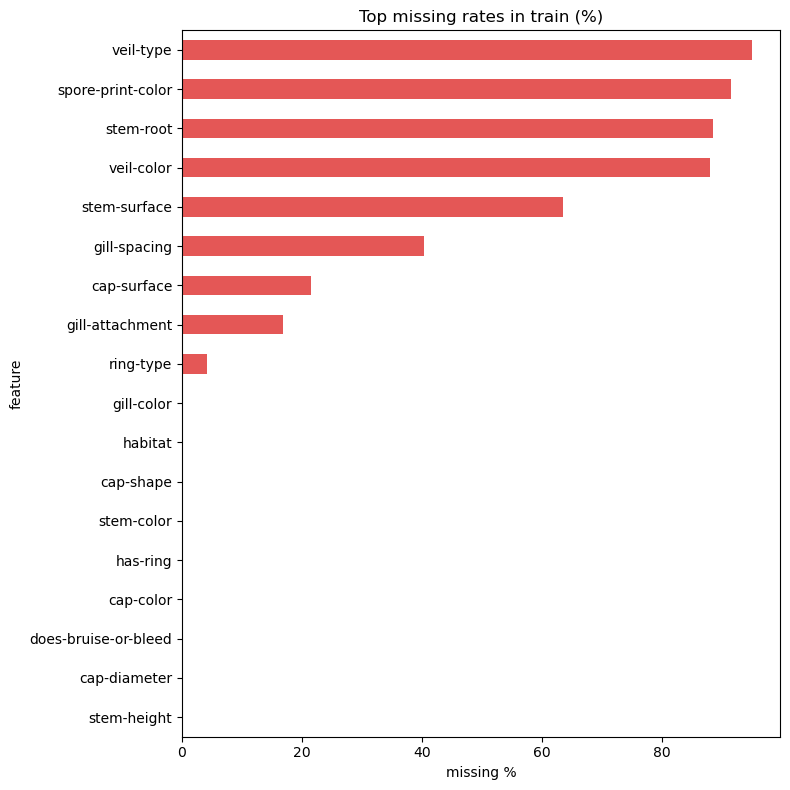

In [4]:
missing_train = train_df.isna().mean().mul(100).sort_values(ascending=False)
missing_test = test_df.isna().mean().mul(100).sort_values(ascending=False)

missing_report = pd.DataFrame(
    {
        "missing_pct_train": missing_train,
        "missing_pct_test": missing_test,
    }
).fillna(0.0)

missing_non_zero = missing_report[(missing_report["missing_pct_train"] > 0) | (missing_report["missing_pct_test"] > 0)]
print(f"Columns with missing values: {len(missing_non_zero)}")
display(missing_non_zero.head(30))

if not missing_non_zero.empty:
    top_missing = missing_non_zero.sort_values("missing_pct_train", ascending=True).tail(25)
    ax = top_missing["missing_pct_train"].plot(kind="barh", figsize=(8, 8), color="#E45756")
    ax.set_title("Top missing rates in train (%)")
    ax.set_xlabel("missing %")
    ax.set_ylabel("feature")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected in train/test.")

In [7]:
cat_cols = train_df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "class"]

rare_threshold = 0.005  # 0.5%
rare_rows = []

for col in cat_cols:
    freq = train_df[col].value_counts(normalize=True, dropna=False)
    rare = freq[freq < rare_threshold]
    rare_rows.append(
        {
            "column": col,
            "n_unique": train_df[col].nunique(dropna=True),
            "n_rare_categories": int(rare.shape[0]),
            "rare_total_pct": round(float(rare.sum() * 100), 3),
        }
    )

rare_summary = pd.DataFrame(rare_rows).sort_values(
    ["n_rare_categories", "rare_total_pct"], ascending=False
)
display(rare_summary.head(20))

# Show top categories for a few high-cardinality columns
for col in rare_summary.head(5)["column"].tolist():
    print(f"\nTop categories for {col}:")
    display(train_df[col].value_counts(dropna=False).head(10).to_frame("count"))

,column,n_unique,n_rare_categories,rare_total_pct
1,cap-surface,83,72,0.019
4,gill-attachment,78,71,0.016
0,cap-shape,74,68,0.018
2,cap-color,78,67,0.012
8,stem-surface,60,53,0.029
6,gill-color,63,52,0.016
9,stem-color,59,50,0.585
15,habitat,52,46,0.185
5,gill-spacing,48,45,0.005
7,stem-root,38,34,0.025



Top categories for cap-surface:


,count
cap-surface,
NaN,671023
t,460777
s,384970
y,327826
h,284460
g,263729
d,206832
k,128875
e,119712



Top categories for gill-attachment:


,count
gill-attachment,
a,646034
d,589236
NaN,523936
x,360878
e,301858
s,295439
p,279110
f,119953
c,74


...

,count
cap-shape,
x,1436026
f,676238
s,365146
b,318646
o,108835
p,106967
c,104520
d,65
e,60



Top categories for cap-color:


,count
cap-color,
n,1359542
y,386627
w,379442
g,210825
e,197290
o,178847
p,91838
r,78236
u,73172



Top categories for stem-surface:


,count
stem-surface,
NaN,1980861
s,327610
y,255500
i,224346
t,147974
g,78080
k,73383
h,28283
f,512


## 4) Train vs Test Consistency Check

Questions to answer:
- Do train and test share the same columns and category space?
- Are there categories present in test but absent in train?


In [8]:
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

missing_in_test = sorted(train_cols - test_cols - {"class"})
extra_in_test = sorted(test_cols - train_cols)

print("Columns in train but not in test (excluding target):", missing_in_test)
print("Columns in test but not in train:", extra_in_test)

common_cat_cols = [
    c for c in train_df.select_dtypes(include=["object", "string"]).columns
    if c in test_df.columns and c != "class"
]

unseen_rows = []
for col in common_cat_cols:
    train_cats = set(train_df[col].dropna().unique())
    test_cats = set(test_df[col].dropna().unique())
    unseen_in_test = test_cats - train_cats
    unseen_rows.append(
        {
            "column": col,
            "train_unique": len(train_cats),
            "test_unique": len(test_cats),
            "unseen_in_test_count": len(unseen_in_test),
            "sample_unseen_in_test": ", ".join(list(sorted(unseen_in_test))[:5]) if unseen_in_test else "",
        }
    )

unseen_report = pd.DataFrame(unseen_rows).sort_values("unseen_in_test_count", ascending=False)
display(unseen_report.head(30))

n_problem_cols = (unseen_report["unseen_in_test_count"] > 0).sum()
print(f"Categorical columns with unseen categories in test: {n_problem_cols}")

Columns in train but not in test (excluding target): []
Columns in test but not in train: []


,column,train_unique,test_unique,unseen_in_test_count,sample_unseen_in_test
4,gill-attachment,78,66,39,"0.87, 0.88, 0.93, 0.95, 1.26"
0,cap-shape,74,62,34,"0.74, 0.93, 0.97, 1.25, 1.53"
1,cap-surface,83,59,31,"0.94, 1.95, 10.09, 11.96, 12.15"
2,cap-color,78,57,31,"0.73, 0.91, 1.83, 10.83, 10.93"
9,stem-color,59,55,29,"10.6, 10.93, 11.0, 11.31, 17.16"
8,stem-surface,60,54,27,"10.14, 11.53, 13.01, 13.09, 15.25"
6,gill-color,63,56,23,"1.55, 10.34, 10.56, 12.87, 17.26"
5,gill-spacing,48,35,18,"1.46, 1.61, 1.64, 1.68, 13.66"
15,habitat,52,39,13,"1.75, 19.85, 2.02, 2.53, 3.19"
14,spore-print-color,32,33,11,"17.72, 2.52, 2.92, 26.48, 27.48"


Categorical columns with unseen categories in test: 16


## 5) End-of-Analysis Summary

### Key findings
- The dataset is large: about 3.12M rows in train and 2.08M rows in test, which supports robust cross-validation.
- The target is mildly imbalanced (`p`: 54.71%, `e`: 45.29%; imbalance ratio ~1.21).
- Several features have very high missing rates (up to ~95%), especially `veil-type`, `spore-print-color`, `stem-root`, and `veil-color`.
- Missing-value rates are very similar in train and test, which reduces distribution-shift risk on this aspect.
- Many categorical features contain categories in test that are not present in train (16 columns affected), so encoding must safely handle unseen levels.

### Preprocessing strategy
- Treat missing values by dropping rows.
- Use an encoding/modeling pipeline that is robust to unknown categories at inference time.
- Keep an initial baseline simple and reproducible, then iterate one change at a time.
